In [98]:
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from nltk import tokenize
import re
from nltk.corpus import stopwords
import nltk
from collections import Counter

In [99]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/denis2104/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/denis2104/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [100]:
@dataclass
class CFG:
    train_file_path: str = 'train_sentiment_analysis.csv'
    test_file_path: str = 'test_sentiment_analysis.csv'
    punctuation_marks: str = ';:-?(),"!.'

In [101]:
def load_csv(file_path):
    dataframe = pd.read_csv(file_path,skiprows=1, names=['index', 'text', 'label'])
    return dataframe

def open_test_and_train_csv():
    return load_csv(CFG.test_file_path), load_csv(CFG.train_file_path)

In [102]:
def see_positive_and_negative_for_a_dataset(dataset):
    positive = dataset[dataset['label'] == 1]
    negative = dataset[dataset['label'] == 0]
    return positive, negative

In [103]:
test, train = open_test_and_train_csv()

In [104]:
def plot_count_plot(values,type_of_element='label', title='Count Plot'):
    plt.figure(figsize=(8,6))
    plt.title(title)
    plt.xlabel(type_of_element)
    plt.ylabel('Count')
    elements = ['Test', 'Train']
    plt.bar(elements, values, color=['blue', 'orange'])
    plt.show()

In [105]:
def plot_positive_vs_negative_for_a_dataset(dataset, type_of_data = 'Train'):
    positive, negative = see_positive_and_negative_for_a_dataset(dataset)
    labels = ['Positive', 'Negative']
    sizes = [len(positive), len(negative)]
    plt.figure(figsize=(6,6))
    plt.bar(labels, sizes, color=['green', 'red'])
    plt.title('Positive vs Negative Sentiments on ' + type_of_data + ' Dataset')
    plt.show()

In [106]:
positive_train, negative_train = see_positive_and_negative_for_a_dataset(train)
positive_test, negative_test = see_positive_and_negative_for_a_dataset(test)

print(f"Train Dataset: Positive samples = {len(positive_train)}, Negative samples = {len(negative_train)}")
print(f"Test Dataset: Positive samples = {len(positive_test)}, Negative samples = {len(negative_test)}")

print(f"Ratio of Positive to Negative in Train Dataset: {len(positive_train) / len(negative_train):.2f}")
print(f"Ratio of Positive to Negative in Test Dataset: {len(positive_test) / len(negative_test):.2f}")

Train Dataset: Positive samples = 11094, Negative samples = 6847
Test Dataset: Positive samples = 6177, Negative samples = 4828
Ratio of Positive to Negative in Train Dataset: 1.62
Ratio of Positive to Negative in Test Dataset: 1.28


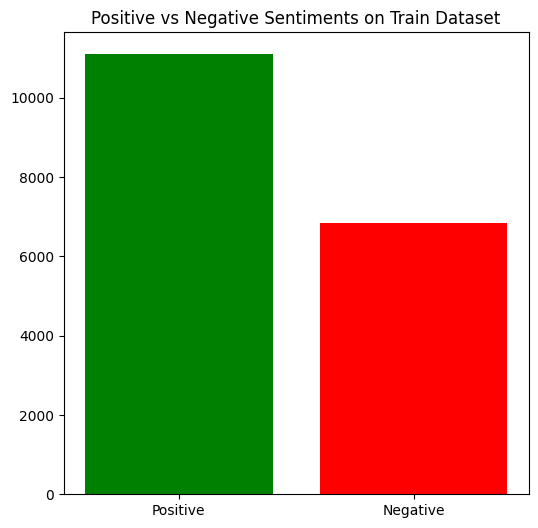

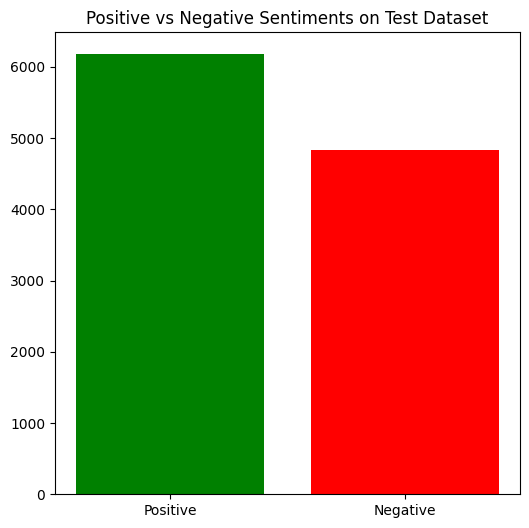

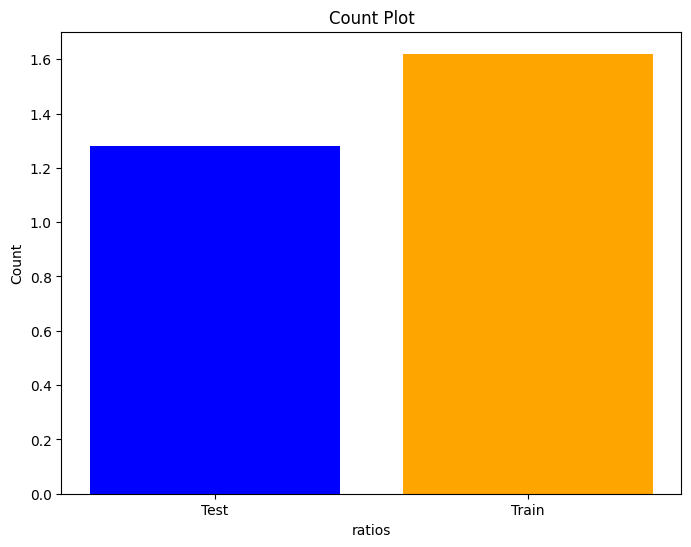

In [107]:
plot_positive_vs_negative_for_a_dataset(train)
plot_positive_vs_negative_for_a_dataset(test, type_of_data='Test')
plot_count_plot([len(positive_test)/len(negative_test),len(positive_train)/len(negative_train)], type_of_element='ratios')

In [108]:
def check_for_empty_values(dataset):
    empty_values = dataset[dataset['text'].isnull() | (dataset['text'].str.strip() == '')]
    return empty_values

In [109]:
empty_values_train = check_for_empty_values(train)
print(f"Empty values in Train Dataset: {len(empty_values_train)}")
if not empty_values_train.empty:
    train = train.drop(empty_values_train.index)
    
empty_values_test = check_for_empty_values(test)
print(f"Empty values in Test Dataset: {len(empty_values_test)}")
if not empty_values_test.empty:
    test = test.drop(empty_values_test.index)

Empty values in Train Dataset: 290
Empty values in Test Dataset: 0


In [110]:
def data_leakage_text(train_dataset, test_dataset):
    train_texts = set(train_dataset['text'])
    test_texts = set(test_dataset['text'])
    overlapping_texts = train_texts.intersection(test_texts)
    print(f"Number of overlapping texts between Train and Test datasets: {len(overlapping_texts)}")
    return overlapping_texts

def discard_data_leakage_examples_from_test(list_of_text_to_remove, test_dataset):
    indexes_to_remove = test_dataset[test_dataset['text'].isin(list_of_text_to_remove)].index
    test_dataset.drop(indexes_to_remove, inplace=True)

In [111]:
discard_data_leakage_examples_from_test(data_leakage_text(train, test), test)

Number of overlapping texts between Train and Test datasets: 56


In [112]:
def make_length_column_for_dataset(dataset):
    dataset['length'] = dataset['text'].str.len()

def make_word_count_column_for_dataset(dataset):
    dataset['word_count'] = dataset['text'].str.split().apply(len)

def make_mean_word_length_column_for_dataset(dataset):
    dataset['mean_word_length'] = dataset['text'].apply(lambda x: sum(len(word) for word in x.split()) / len(x.split()) if len(x.split()) > 0 else 0)

def make_mean_sentence_length_column_for_dataset(dataset):
    dataset['mean_sentence_length'] = dataset['text'].apply(lambda x: sum(len(sentence) for sentence in tokenize.sent_tokenize(x)) / len(tokenize.sent_tokenize(x)) if len(tokenize.sent_tokenize(x)) > 0 else 0)

In [113]:
def punctuation_marks_in_text(dataset):
    punctuation_set = set()
    for text in dataset['text']:
        for char in text:
            punctuation_set.add(char)
    
    return punctuation_set

In [114]:
def lead_trailing_dot_punctuation_removal(text):
    return re.findall(r'([!?.,:;\'"()-]{2,})(?=\s|$)', text)

In [115]:
def see_pattern_of_punctuation_marks_in_text(dataset):  
    list_of_patterns_in_train = [lead_trailing_dot_punctuation_removal(text) for text in dataset['text']] 
    return Counter([item for sublist in list_of_patterns_in_train if sublist for item in sublist])

In [116]:
def make_sentences_from_text_column(dataset):
    dataset['sentences'] = dataset['text'].apply(lambda x: tokenize.sent_tokenize(x))

def make_a_clean_sentence(sentence):

    sentence = sentence.lower()
    sentence = re.sub(r'[^a-zA-Z0-9\s-]+', '', sentence)
    sentence = " ".join([word for word in sentence.split()])
    
    return sentence

def make_clean_sentences_from_text_column(dataset):
    dataset['clean_sentences'] = dataset['sentences'].apply(lambda sentences: [make_a_clean_sentence(sentence) for sentence in sentences])

In [117]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

def make_a_clean_text(dataset):
    dataset['clean_text'] = dataset['text'].apply(clean_text)

In [118]:
make_length_column_for_dataset(train)
make_length_column_for_dataset(test)

make_word_count_column_for_dataset(train)
make_word_count_column_for_dataset(test)

make_mean_word_length_column_for_dataset(train)
make_mean_word_length_column_for_dataset(test)

make_mean_sentence_length_column_for_dataset(train)
make_mean_sentence_length_column_for_dataset(test)

make_sentences_from_text_column(train)
make_sentences_from_text_column(test)

make_clean_sentences_from_text_column(train)
make_clean_sentences_from_text_column(test)

make_a_clean_text(train)
make_a_clean_text(test)

In [119]:
def check_for_duplicate_values(dataset):
    duplicate_values = dataset[dataset.duplicated(subset=['clean_text'], keep=False)]
    return duplicate_values

In [120]:
duplicate_text_in_train = check_for_duplicate_values(train)
duplicate_text_in_test = check_for_duplicate_values(test)

print(f"Duplicate values in Train Dataset: {len(duplicate_text_in_train)}")
print(f"Duplicate values in Test Dataset: {len(duplicate_text_in_test)}")

Duplicate values in Train Dataset: 1921
Duplicate values in Test Dataset: 322


In [121]:
def see_positive_negative_sentiments_per_duplicate_text(duplicate_dataset):
    text_with_positive_and_negative_counts = []
    grouped = duplicate_dataset.groupby('clean_text')
    for name, group in grouped:
        positive_count = len(group[group['label'] == 1])
        negative_count = len(group[group['label'] == 0])
        text_with_positive_and_negative_counts.append((name, (positive_count, negative_count)))
        
    return text_with_positive_and_negative_counts

In [ ]:
list_of_duplicates_in_train = see_positive_negative_sentiments_per_duplicate_text(duplicate_text_in_train)
list_of_duplicates_in_test = see_positive_negative_sentiments_per_duplicate_text(duplicate_text_in_test)

for text, (pos_count, neg_count) in list_of_duplicates_in_train:
    if pos_count != neg_count:
        print(f"Text: {text}\nPositive Count: {pos_count}, Negative Count: {neg_count}\n")

Text: 
Positive Count: 3, Negative Count: 1

Text: 0 stele nu corespunde descrierii a mirosit la inceput iar acum nici nu se mai simte
Positive Count: 0, Negative Count: 2

Text: 2 cuvinte in engleza the best iar in romana 3 cel mai bunatata tot
Positive Count: 4, Negative Count: 0

Text: 2 lei se aude foarte incet si scote un sunet ciudat nu recomand ceea mai proasta achizitie din viata mea
Positive Count: 0, Negative Count: 6

Text: 2 ore si jumate deceva nemaivazute fantastic din toate punctele de vederechiar ma impresionat pacat ca tine doar 2 ore jumate puritatea culturii navifilozofia lor de viataideile frumoaselimbajulpandorra un intreg univers marca james cameronacest film merita vazut de toata lumea oriunde oricand oricum
Positive Count: 5, Negative Count: 0

Text: 230 lei o anvelopa saptamana 23 anul 2016 2316 se comporta foarte bine in conditiile de zapada si gheata am un c5 brake si am incercat sa opresc masina pe o panta cu zapada de la 60 de kmh la 0kmh sa oprit fara nici